##### Hypothesis: Keyword influacne rating and votes

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#0. Load data
data_path = "../../data/European_data_2000.csv"

df = pd.read_csv(
    data_path,
    sep=",",
    engine="python",
    quotechar='"',
    on_bad_lines="skip"   
)

Metric: There are 0 movies with 0 keywords (0.00% of the dataset).


/Users/meike/anaconda3/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


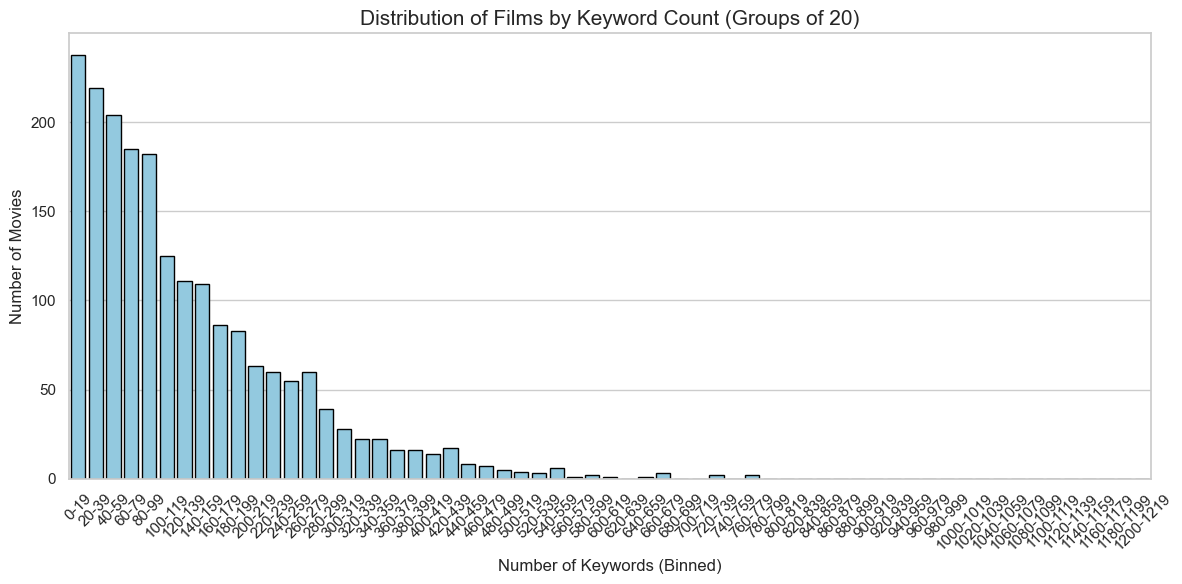

Average number of keywords: 132.36


In [15]:
# 1. Calculate Keyword Count
# We treat empty strings or NaNs as 0 keywords
df['keyword_count'] = df['keywords'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) and x != '' else 0)

# 2. METRIC: Movies with 0 Keywords
zero_kw_count = (df['keyword_count'] == 0).sum()
total_movies = len(df)
print(f"Metric: There are {zero_kw_count} movies with 0 keywords ({ (zero_kw_count/total_movies)*100:.2f}% of the dataset).")

# 3. Binning the Keyword Counts into groups of 5
# We create bins: [0, 5, 10, 15, ..., max+5]
max_kw = int(df['keyword_count'].max())
bins = list(range(0, max_kw + 6, 20))
labels = [f"{i}-{i+19}" for i in bins[:-1]]

df['kw_bins'] = pd.cut(df['keyword_count'], bins=bins, labels=labels, right=False)

# Set visual style
sns.set_theme(style="whitegrid")

# --- VISUALIZATION 1: Distribution of Binned Keyword Counts ---
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='kw_bins', color='skyblue', edgecolor='black')
plt.title('Distribution of Films by Keyword Count (Groups of 20)', fontsize=15)
plt.xlabel('Number of Keywords (Binned)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df['keyword_count'] = df['keywords'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) and x != '' else 0)
print(f"Average number of keywords: {df['keyword_count'].mean():.2f}")




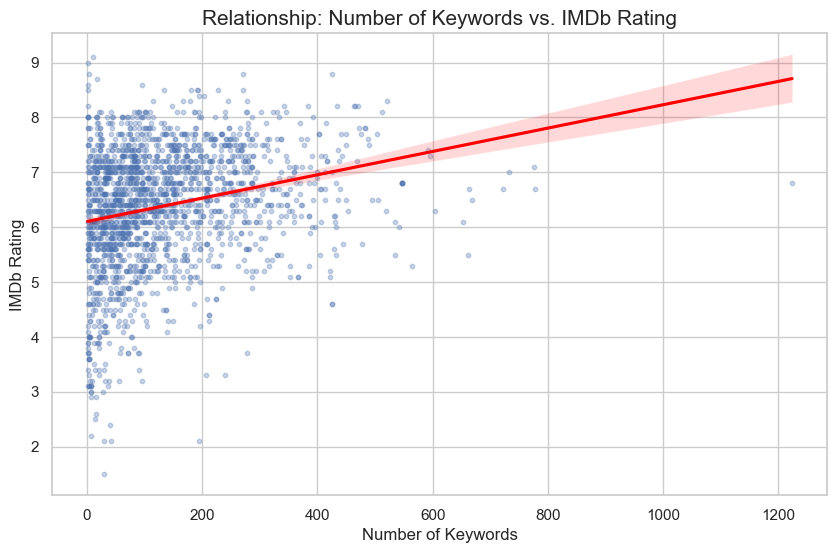

In [16]:
# --- VISUALIZATION 2: Keywords vs IMDb Rating ---
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='keyword_count', y='imdbRating', 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
plt.title('Relationship: Number of Keywords vs. IMDb Rating', fontsize=15)
plt.xlabel('Number of Keywords', fontsize=12)
plt.ylabel('IMDb Rating', fontsize=12)
plt.show()

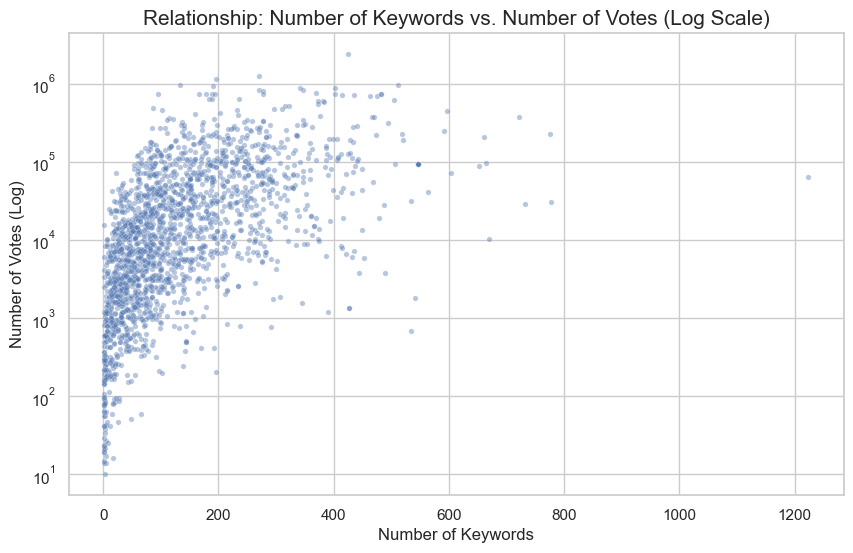

Correlation Matrix:
keyword_count    1.000000
imdbRating       0.239988
numberOfVotes    0.391785
Name: keyword_count, dtype: float64


In [17]:
# --- VISUALIZATION 3: Keywords vs Number of Votes ---
# Note: numberOfVotes often follows a power-law distribution, so a log scale helps visibility.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='keyword_count', y='numberOfVotes', alpha=0.4, s=15)
plt.yscale('log')  # Using log scale for votes to handle high variance
plt.title('Relationship: Number of Keywords vs. Number of Votes (Log Scale)', fontsize=15)
plt.xlabel('Number of Keywords', fontsize=12)
plt.ylabel('Number of Votes (Log)', fontsize=12)
plt.show()

# --- Statistical Check: Correlation ---
correlations = df[['keyword_count', 'imdbRating', 'numberOfVotes']].corr()
print("Correlation Matrix:")
print(correlations['keyword_count'])

### Insights
The relationship between keywords and ratings is positive but weak, meaning that more keywords also have better ratings. 
The relationship between keywords and votes is stronger, suggesting that keywords with more votes also have more keywords.
* More keywords open the movie to a wider audience.
* However, this could also mean that a popular movie brings more engagement from fans who leave more keywords on IMDb.
### Questions: 
* How are keywords set? 
* How can you identify which keywords are set by the community and which are from the production team?
* As votes are a good indicator of box office performance, what about keywords? 

## Sentiment analysis

First try with VADER. But maybe the model needs to be changed to BERT

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if pd.isnull(text) or text == '':
        return 0
    return sia.polarity_scores(str(text))['compound']

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/meike/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


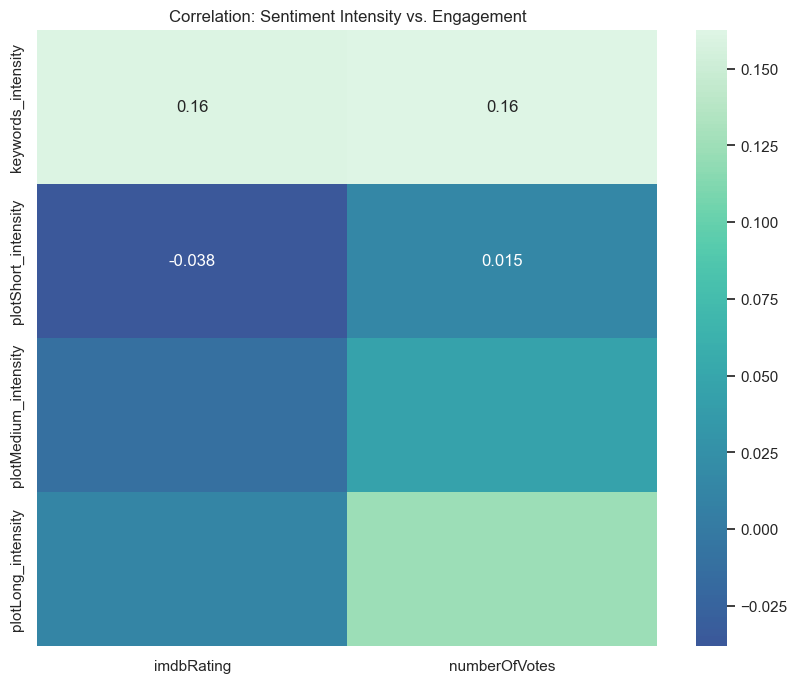

                      keywords_intensity  plotShort_intensity  \
keywords_intensity              1.000000             0.077809   
plotShort_intensity             0.077809             1.000000   
plotMedium_intensity            0.034192             0.157081   
plotLong_intensity              0.161394             0.036516   
imdbRating                      0.159633            -0.037992   
numberOfVotes                   0.162678             0.015095   

                      plotMedium_intensity  plotLong_intensity  imdbRating  \
keywords_intensity                0.034192            0.161394    0.159633   
plotShort_intensity               0.157081            0.036516   -0.037992   
plotMedium_intensity              1.000000            0.089032   -0.011394   
plotLong_intensity                0.089032            1.000000    0.011518   
imdbRating                       -0.011394            0.011518    1.000000   
numberOfVotes                     0.045044            0.122740    0.330063  

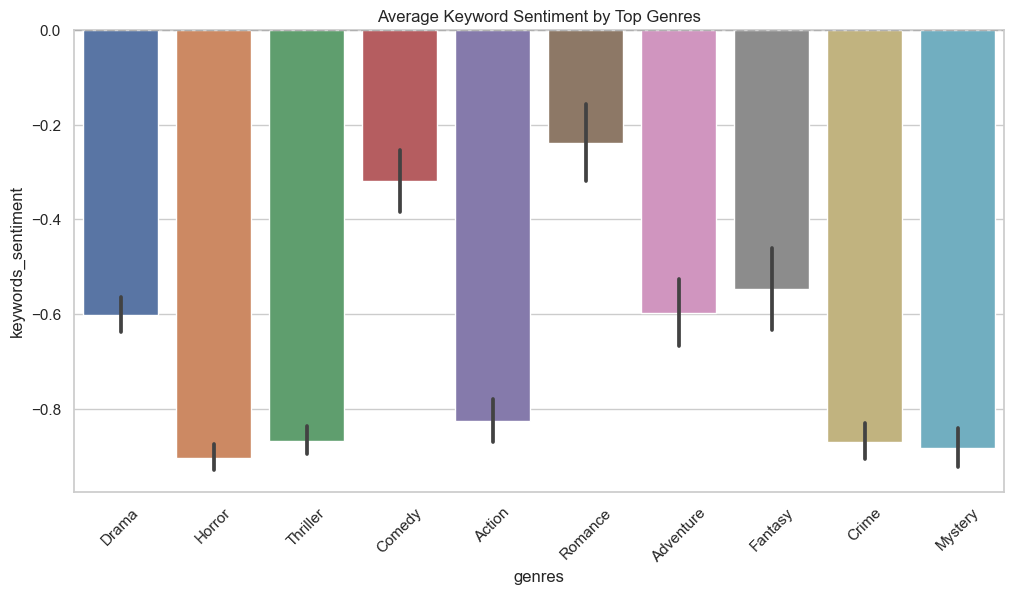

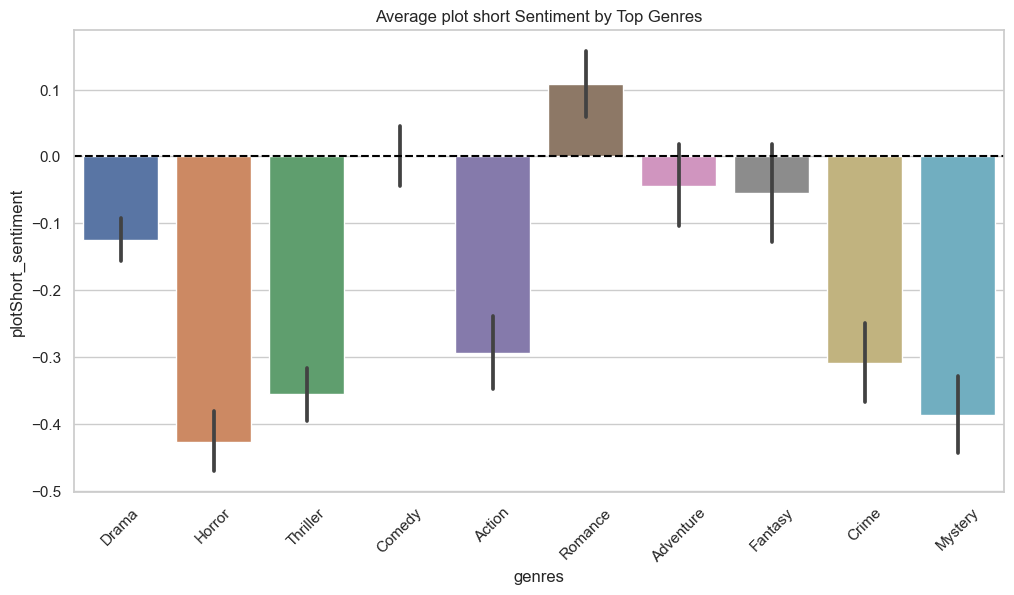

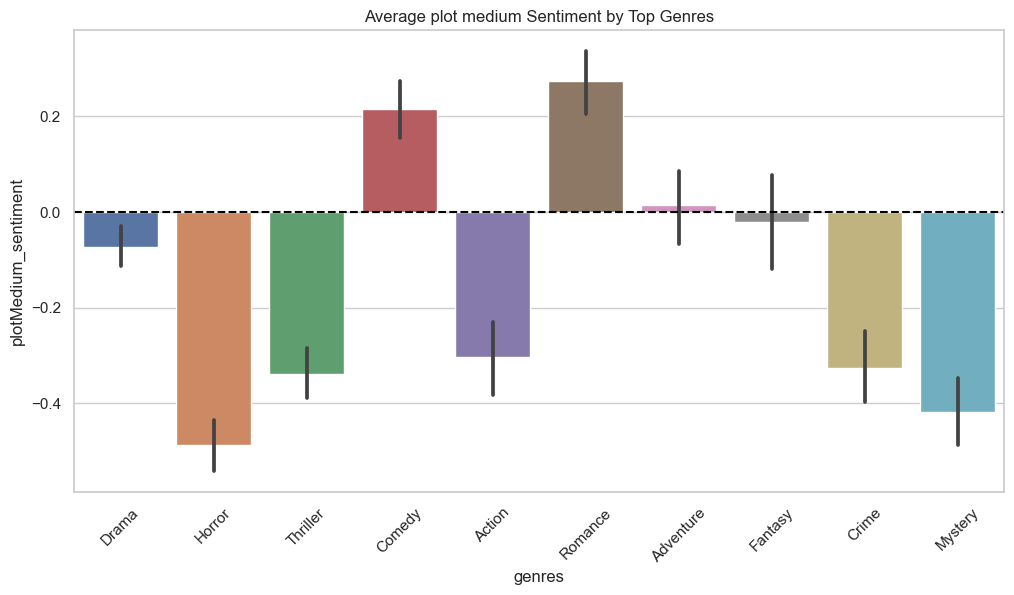

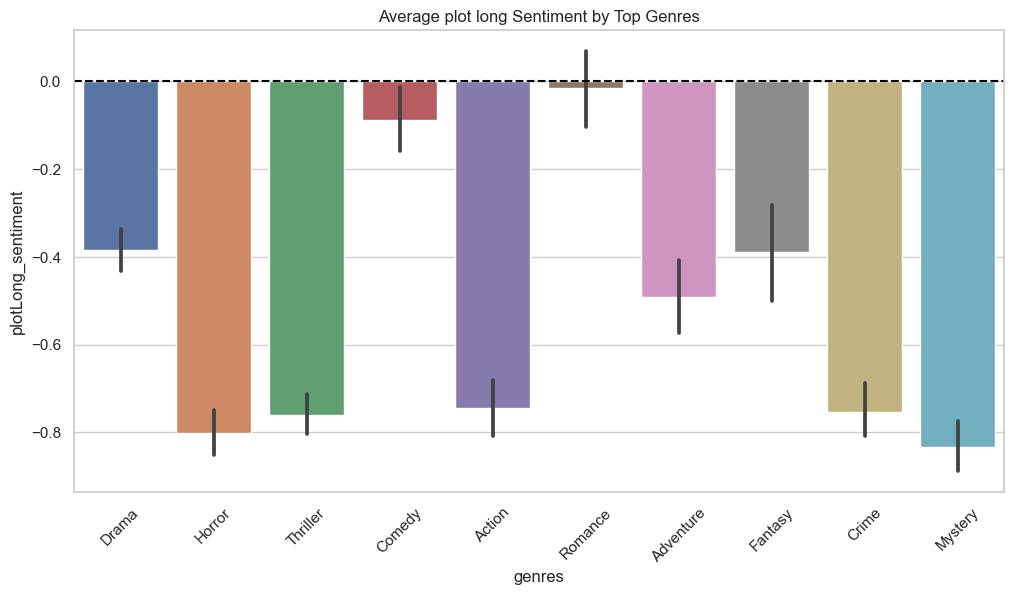

In [30]:
# 1. Calculate Sentiment for Keywords and Plots
cols_to_analyze = ['keywords', 'plotShort', 'plotMedium', 'plotLong']

for col in cols_to_analyze:
    # Get the raw sentiment (-1 to 1)
    df[f'{col}_sentiment'] = df[col].apply(get_sentiment)
    # Get the intensity (0 to 1) - because "Strong" sentiment can be +/-
    df[f'{col}_intensity'] = df[f'{col}_sentiment'].abs()

# 2. Correlation Check
sentiment_cols = [f'{col}_intensity' for col in cols_to_analyze]
engagement_cols = ['imdbRating', 'numberOfVotes']
corr_matrix = df[sentiment_cols + engagement_cols].corr()

# --- Visualization 1: Heatmap of Sentiment vs Engagement ---
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[engagement_cols].loc[sentiment_cols], annot=True, cmap='mako', center=0)
plt.title('Correlation: Sentiment Intensity vs. Engagement')
plt.show()
print(corr_matrix)

# 3. Genre Analysis
# We need to split movies that have multiple genres like "Drama, Comedy"
df_genre = df.assign(genres=df['genres'].str.split(',')).explode('genres')
df_genre['genres'] = df_genre['genres'].str.strip()

# --- Visualization 2: Sentiment Strategy by Genre ---
# Let's look at keywords sentiment vs Rating across top genres
top_genres = df_genre['genres'].value_counts().nlargest(10).index
df_top_genres = df_genre[df_genre['genres'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_genres, x='genres', y='keywords_sentiment', hue=None)
plt.axhline(0, color='black', linestyle='--')
plt.title('Average Keyword Sentiment by Top Genres')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_genres, x='genres', y='plotShort_sentiment', hue=None)
plt.axhline(0, color='black', linestyle='--')
plt.title('Average plot short Sentiment by Top Genres')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_genres, x='genres', y='plotMedium_sentiment', hue=None)
plt.axhline(0, color='black', linestyle='--')
plt.title('Average plot medium Sentiment by Top Genres')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_genres, x='genres', y='plotLong_sentiment', hue=None)
plt.axhline(0, color='black', linestyle='--')
plt.title('Average plot long Sentiment by Top Genres')
plt.xticks(rotation=45)
plt.show()

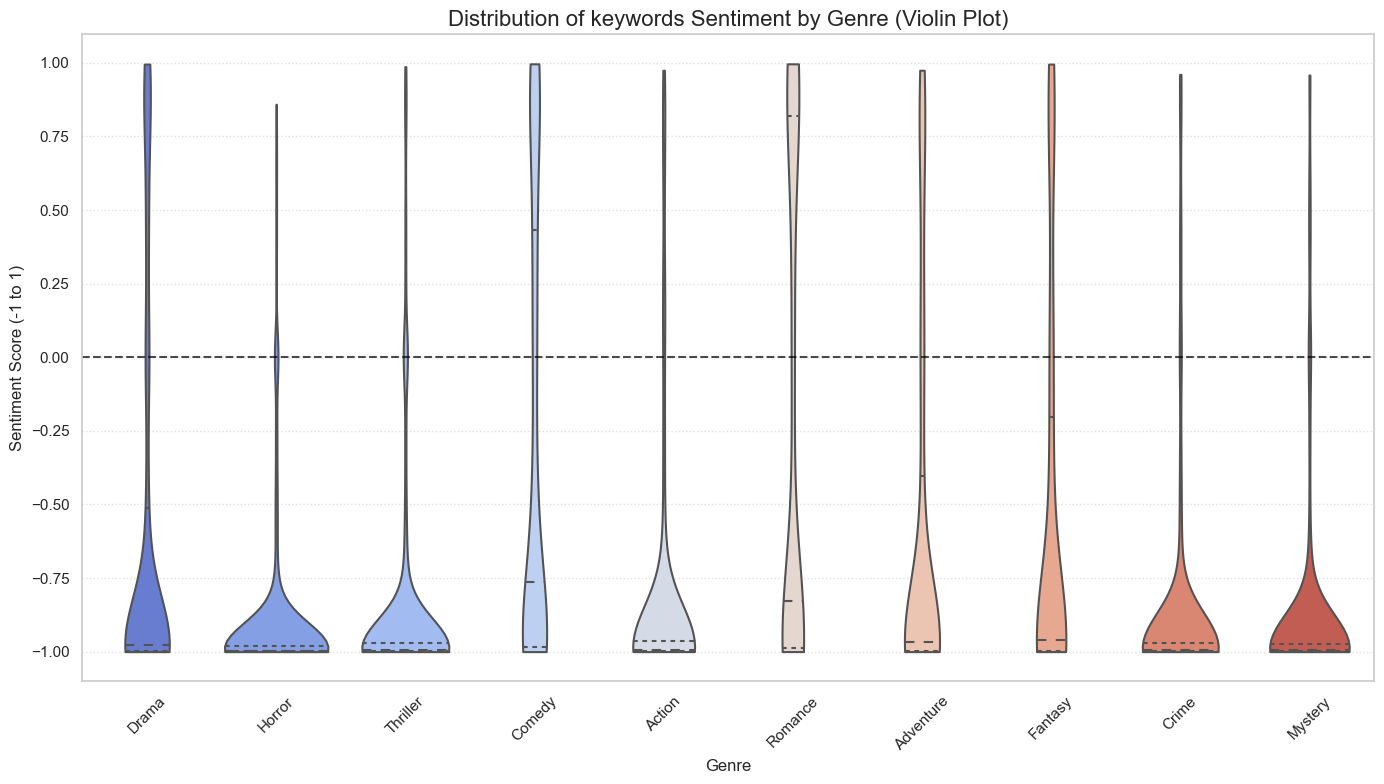

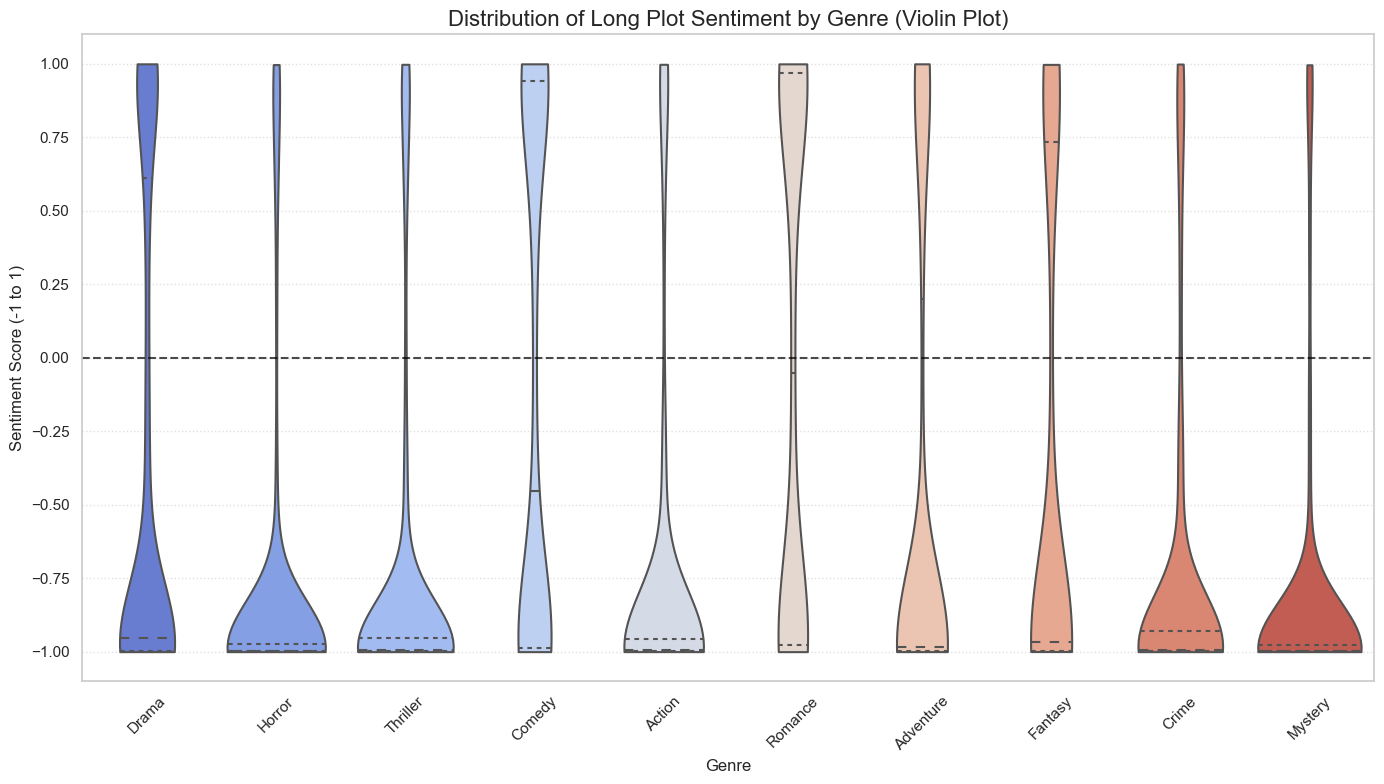

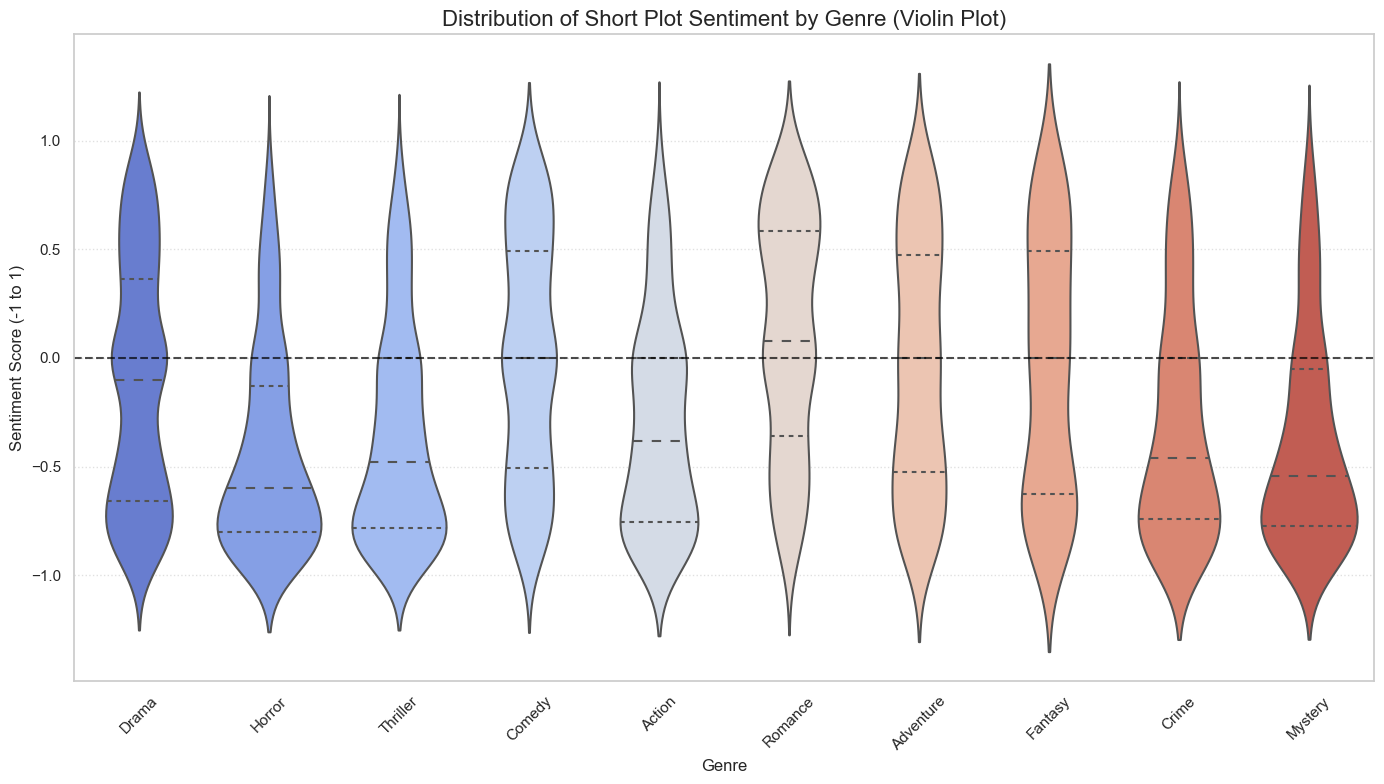

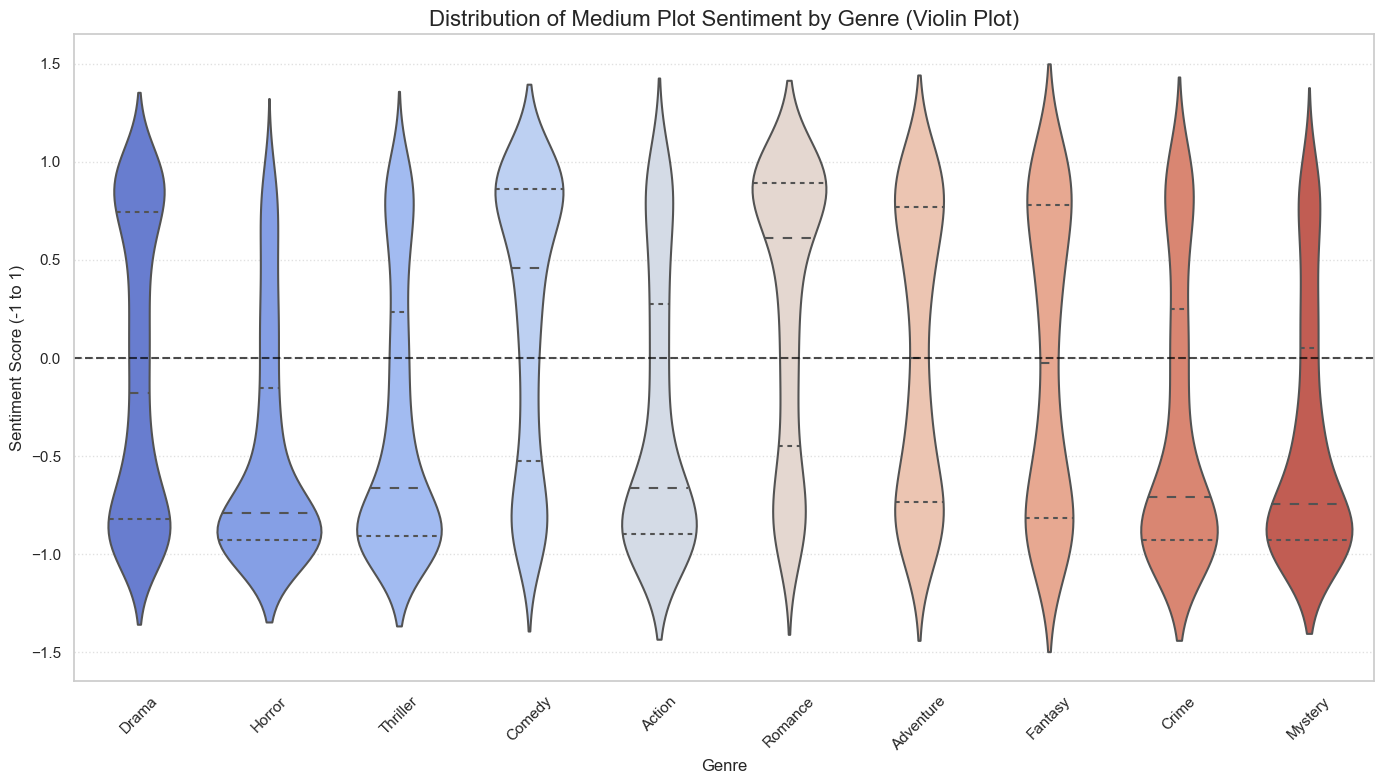

In [32]:
plt.figure(figsize=(14, 8))
# Create the Violin Plot
sns.violinplot(data=df_top_genres, x='genres', y='keywords_sentiment', 
               palette="coolwarm", inner="quartile", cut=0)
# Add a reference line at 0 (Neutral)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Distribution of keywords Sentiment by Genre (Violin Plot)', fontsize=16)
plt.ylabel('Sentiment Score (-1 to 1)', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
# Create the Violin Plot
sns.violinplot(data=df_top_genres, x='genres', y='plotLong_sentiment', 
               palette="coolwarm", inner="quartile", cut=0)
# Add a reference line at 0 (Neutral)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Distribution of Long Plot Sentiment by Genre (Violin Plot)', fontsize=16)
plt.ylabel('Sentiment Score (-1 to 1)', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
# Create the Violin Plot
sns.violinplot(data=df_top_genres, x='genres', y='plotShort_sentiment', 
               palette="coolwarm", inner="quartile")
# Add a reference line at 0 (Neutral)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Distribution of Short Plot Sentiment by Genre (Violin Plot)', fontsize=16)
plt.ylabel('Sentiment Score (-1 to 1)', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 8))
# Create the Violin Plot
sns.violinplot(data=df_top_genres, x='genres', y='plotMedium_sentiment', 
               palette="coolwarm", inner="quartile")
# Add a reference line at 0 (Neutral)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Distribution of Medium Plot Sentiment by Genre (Violin Plot)', fontsize=16)
plt.ylabel('Sentiment Score (-1 to 1)', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Ensure VADER is ready
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# 1. Helper function to categorize sentiment
def categorize_sentiment(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

# 2. Sentiment Calculation (if not already done)
text_cols = ['keywords', 'plotShort'] # Using these two as primary indicators
for col in text_cols:
    df[f'{col}_sentiment_score'] = df[col].apply(lambda x: sia.polarity_scores(str(x))['compound'] if pd.notnull(x) else 0)
    df[f'{col}_sentiment_type'] = df[f'{col}_sentiment_score'].apply(categorize_sentiment)

# 3. Process Genres (Explode so each film counts for each of its genres)
df_exploded = df.assign(genres=df['genres'].str.split(',')).explode('genres')
df_exploded['genres'] = df_exploded['genres'].str.strip()

# 4. Filter for Top Genres (to keep the table readable)
top_genres = df_exploded['genres'].value_counts().nlargest(15).index
df_top = df_exploded[df_exploded['genres'].isin(top_genres)]

# 5. Create the Strategy Table Logic
# We want to find which sentiment type has the highest mean rating per genre
strategy_data = []

for genre in top_genres:
    genre_subset = df_top[df_top['genres'] == genre]
    
    # Keyword Strategy
    best_kw_sent = genre_subset.groupby('keywords_sentiment_type')['imdbRating'].mean().idxmax()
    kw_rating = genre_subset.groupby('keywords_sentiment_type')['imdbRating'].mean().max()
    
    # Plot Strategy
    best_plot_sent = genre_subset.groupby('plotShort_sentiment_type')['imdbRating'].mean().idxmax()
    plot_rating = genre_subset.groupby('plotShort_sentiment_type')['imdbRating'].mean().max()
    
    # Average Votes for context
    avg_votes = genre_subset['numberOfVotes'].median()
    
    strategy_data.append({
        'Genre': genre,
        'Recommended Keyword Vibe': best_kw_sent,
        'Recommended Plot Vibe': best_plot_sent,
        'Target Rating (Est.)': round(kw_rating, 2),
        'Typical Genre Reach (Median Votes)': int(avg_votes)
    })

strategy_df = pd.DataFrame(strategy_data)

# Display the table
print("--- STRATEGY TABLE FOR DIRECTORS ---")
print(strategy_df.to_string(index=False))

# Optional: Save to CSV for your report
# strategy_df.to_csv('genre_sentiment_strategy.csv', index=False)

--- STRATEGY TABLE FOR DIRECTORS ---
    Genre Recommended Keyword Vibe Recommended Plot Vibe  Target Rating (Est.)  Typical Genre Reach (Median Votes)
    Drama                 Negative              Positive                  6.69                               13639
 Thriller                 Negative              Positive                  6.28                               18785
   Comedy                 Negative              Positive                  6.34                               13073
  Romance                 Negative               Neutral                  6.57                               13220
   Horror                 Negative              Positive                  5.78                                7448
Adventure                 Negative              Positive                  6.24                               20380
    Crime                 Negative              Negative                  6.58                               19543
   Action                 Negative         

In [22]:
# Check how many movies are actually in each category for Comedy
comedy_check = df_top[df_top['genres'] == 'Comedy']
print(comedy_check['keywords_sentiment_type'].value_counts())

# Check the actual mean ratings to see how close they are
print(comedy_check.groupby('keywords_sentiment_type')['imdbRating'].mean())

keywords_sentiment_type
Negative    342
Positive    171
Neutral      17
Name: count, dtype: int64
keywords_sentiment_type
Negative    6.338596
Neutral     5.776471
Positive    6.245029
Name: imdbRating, dtype: float64
